## Приближенный вариационный вывод

В процессе байесовского вывода, нам необходимо найти апостериорное распределение p(z|x)
$$ p(z|x) = \frac{p(x|z)p(z)}{\int p(x|z)p(z)dz}\tag{1} $$
Что делать, если интеграв в (1) аналитически не берется. Одним из подходов к решению - приближенный вариационный вывод, в котором вводится новое распределение q(z|x). Мы хотим добиться того, чтобы q(z|x) было как можно 'ближе' к p(z|x), т.е. решим задачу минимизации расстояния между двумя распределениями q и p:
$$ KL(q(z|x)||p(z|x)) \rightarrow \underset{q(z|x)}{\min} $$



Для вывода, будем минимизировать KL между двумя распределениями
$$ KL(q(z|x)||p(z|x)) = \int q(z|x) \ln \frac{q(z|x)}{p(z|x)}dz = \int q(z|x) \ln q(z|x)dz - \int q(z|x) \ln p(z|x)dz\tag{2} $$

По формуле Байеса
$$ p(z|x) = \frac{p(x|z)p(z)}{p(x)} = \frac{p(x,z)}{p(x)}\tag{3}$$
Подставляем (3) в 2:
$$ KL(q(z|x)||p(z|x)) = \int q(z|x) \ln q(z|x)dz  - \int q(z|x) \ln \frac{p(x,z)}{p(x)}dz\tag{4}$$

Последнее слагаемое в (4):
$$ \int q(z|x) \ln \frac{p(x,z)}{p(x)}dz = \int q(z|x) \ln p(x,z)dz - \int q(z|x) \ln p(x)dz = \int q(z|x) \ln p(x,z)dz - \ln p(x)\int q(z|x) dz $$
Здесь вынесли за знак интеграла $\ln p(x)$ т.к. он не зависит от z и учитывая, что $\int q(z|x)dz = 1$, поскольку берем интеграл по распредлению, получим:
$$ \int q(z|x) \ln \frac{p(x,z)}{p(x)}dz = \int q(z|x) \ln p(x,z)dz - \int q(z|x) \ln p(x)dz = \int q(z|x) \ln p(x,z)dz - \ln p(x)\tag{5} $$
Подставим (5) в (4):

$$ KL(q(z|x)||p(z|x)) = \int q(z|x) \ln q(z|x)dz  - \int q(z|x) \ln p(x,z)dz + \ln p(x)\Rightarrow$$

$$\Rightarrow \ln p(x) =   -\int q(z|x) \ln q(z|x)dz  +\int q(z|x) \ln p(x,z)dz + KL(q(z|x)||p(z|x))$$

Перепише последнее выражение используя выражение для полной вероятности $ p(x,z) = p(x|z)p(z)$, получим
$$ \ln p(x) =   -\int q(z|x) \ln q(z|x)dz  +\int q(z|x) \ln p(x|z)dz +\int q(z|x) \ln p(z)dz+ KL(q(z|x)||p(z|x))\tag{6}$$

В итоге, получили, что левая часть не зависит от z - это const(z). По постановке задачи мы должны найти такое распределение q(z|x), которое минимизирует расстояние между исходным распределением p(z|x) и q(z|x), т.е. минимизировать KL(q(z|x)||p(z|x)). Напрямую мы не можем минимизировать KL, т.к. не знаем p(z|x) (если бы знали, то в явном виде выписали (1)). Но если по z мы сможем максимизировать другие члены выражения (6), тогда KL будет минимизироваться исходя из того, что все выражение есть константа по z. Записшем (6) в следующем виде:


$$ \ln p(x) =  ELBO+ KL(q(z|x)||p(z|x))\tag{7}$$
где 
$$ELBO = -\int q(z|x) \ln q(z|x)dz  +\int q(z|x) \ln p(x|z)dz +\int q(z|x) \ln p(z)dz = \int q(z|x) \ln p(x|z)dz - \int q(z|x) \ln\frac {q(z|x)}{p(z)}dz$$
В более компактной форме:
$$ELBO  = E_{ q(z|x)} \ln p(x|z) - E_{ q(z|x)} \ln\frac {q(z|x)}{p(z)}\rightarrow \underset{q(z|x)}{\max}$$
Таки образом мы перешли от задачи минимизации KL к задачи максимизации ELBO

### Пример: используя приближенный вариационный вывод найти распределение на параметр линейной регрессии

Задача: оценить параметр (найти распределение параметра) w линейной регрессии $ y = wx + noise$  
Априорное распределение $p(w) = N(w|0,\tau^2)$  
Правдоподобие - нормальное распределение с матожиданием $Xw$ и дисперсией $\sigma^2$
$$ p(w|y) = \frac{p(y|w)p(w)}{p(y)}=\frac{N(y|Xw,\sigma^2)N(w|0,\tau^2)}{p(y)} $$

$$ q(w|y) \approx p(w|y)$$
Ищем $q(w|y)$ в виде нормального распределения $N(w|\mu_w,\sigma^2_w)$ и находим параметры $\mu_w$ и $\sigma^2_w$, которые максимизируют:

$$ ELBO = E_q[\ln\frac{p(y,w)}{q(w)}] = E_q[\ln\frac{p(y|w)p(w)}{q(w)}] = E_q \ln p(y|w) + E_q\ln p(w) - E_q\ln q(w) $$

Итерация 100/10000, ELBO: -392.7386, mu_q: 2.0460, sigma_q: 0.2026
Итерация 200/10000, ELBO: 83.1953, mu_q: 2.0199, sigma_q: 0.1296
Итерация 300/10000, ELBO: 83.1443, mu_q: 2.0530, sigma_q: 0.1008
Итерация 400/10000, ELBO: 69.7752, mu_q: 1.9663, sigma_q: 0.0817
Итерация 500/10000, ELBO: 62.1900, mu_q: 2.0505, sigma_q: 0.0687
Итерация 600/10000, ELBO: 72.7418, mu_q: 2.0189, sigma_q: 0.0586
Итерация 700/10000, ELBO: 77.0382, mu_q: 2.0128, sigma_q: 0.0537
Итерация 800/10000, ELBO: 80.9305, mu_q: 2.0446, sigma_q: 0.0488
Итерация 900/10000, ELBO: 80.8009, mu_q: 1.9798, sigma_q: 0.0448
Итерация 1000/10000, ELBO: 79.1788, mu_q: 1.9881, sigma_q: 0.0420
Итерация 1100/10000, ELBO: 81.9852, mu_q: 1.9933, sigma_q: 0.0390
Итерация 1200/10000, ELBO: 78.3112, mu_q: 1.9891, sigma_q: 0.0373
Итерация 1300/10000, ELBO: 81.9754, mu_q: 2.0192, sigma_q: 0.0353
Итерация 1400/10000, ELBO: 80.4972, mu_q: 1.9893, sigma_q: 0.0337
Итерация 1500/10000, ELBO: 81.9045, mu_q: 2.0028, sigma_q: 0.0323
Итерация 1600/100

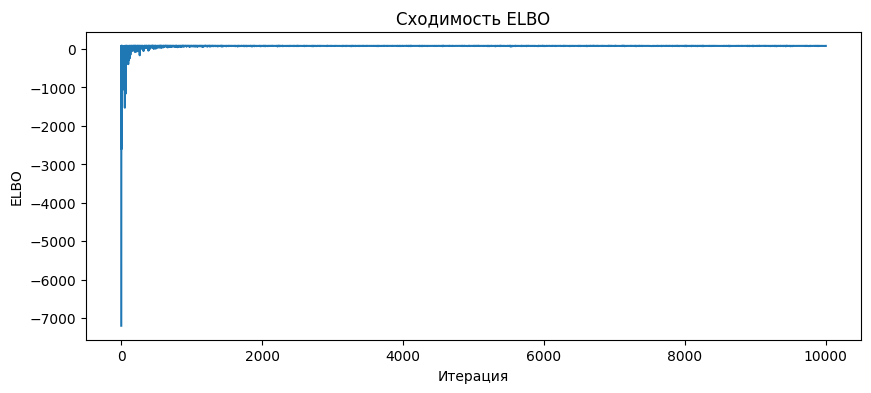

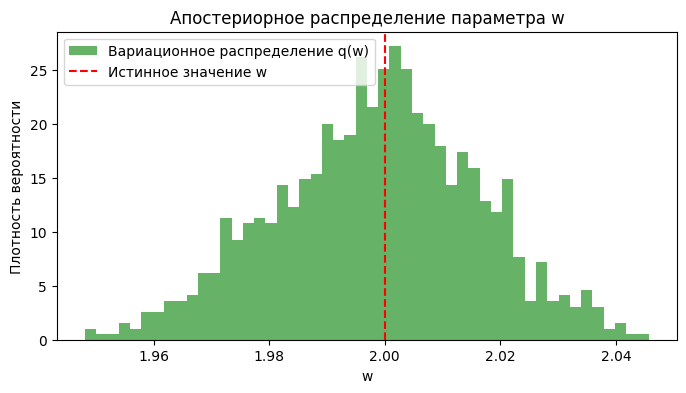

In [2]:
import numpy as np
import torch
import torch.optim as optim
from torch.distributions import Normal
import matplotlib.pyplot as plt

# для воспроизводимости
np.random.seed(0)
torch.manual_seed(0)

# Генерация синтетических данных
true_w = 2.0
num_samples = 100
x = np.linspace(0, 1, num_samples)
noise_std = 0.1
y = true_w * x + np.random.normal(0, noise_std, size=num_samples)

# Преобразование данных в тензоры PyTorch
x_tensor = torch.tensor(x, dtype=torch.float32).unsqueeze(1)  # форма (N, 1)
y_tensor = torch.tensor(y, dtype=torch.float32).unsqueeze(1)  # форма (N, 1)

# Определение вариационных параметров: среднее и log-дисперсия
# Инициализируем их случайно
mu_q = torch.randn(1, requires_grad=True)
log_sigma_q = torch.randn(1, requires_grad=True)

# Определение оптимизатора
optimizer = optim.Adam([mu_q, log_sigma_q], lr=0.05)

# Количество итераций оптимизации
num_iterations = 10000

# Предположим, что априорное распределение для w - N(0, 1)
prior = Normal(torch.tensor([0.0]), torch.tensor([1.0]))


# Функция ELBO (Evidence Lower Bound)
def elbo(x, y, mu_q, log_sigma_q):
    # Вариационная аппроксимация q(w) = N(mu_q, sigma_q^2)
    sigma_q = torch.exp(log_sigma_q)
    q_dist = Normal(mu_q, sigma_q)

    # Выборка из q(w) для оценки ожидаемого значения
    w_sample = q_dist.rsample()

    # Логарифм правдоподобия p(y|x,w)
    # Предполагаем, что p(y|x,w) = N(w*x, noise_std^2)
    likelihood = Normal(w_sample * x, noise_std)
    log_p_y = torch.sum(likelihood.log_prob(y))

    # Логарифм априорного p(w)
    log_p_w = prior.log_prob(w_sample)

    # Логарифм вариационной аппроксимации q(w)
    log_q_w = q_dist.log_prob(w_sample)

    # ELBO = E_q[log p(y, w)] - E_q[log q(w)]
    elbo = log_p_y + log_p_w - log_q_w
    return elbo


# Оптимизационный цикл
elbo_values = []
for i in range(num_iterations):
    optimizer.zero_grad()
    current_elbo = elbo(x_tensor, y_tensor, mu_q, log_sigma_q)
    # Мы хотим максимизировать ELBO, поэтому умножаем на -1 для минимизации
    loss = -current_elbo
    loss.backward()
    optimizer.step()

    elbo_values.append(current_elbo.item())

    if (i + 1) % 100 == 0:
        print(
            f"Итерация {i+1}/{num_iterations}, ELBO: {current_elbo.item():.4f}, mu_q: {mu_q.item():.4f}, sigma_q: {torch.exp(log_sigma_q).item():.4f}"
        )

# Визуализация результатов

mu = mu_q.detach().item()
sigma = torch.exp(log_sigma_q).detach().item()

print(f"nОценка апостериорного распределения:")
print(f"mu = {mu:.4f}")
print(f"sigma = {sigma:.4f}")

# Визуализируем ELBO за итерациями
plt.figure(figsize=(10, 4))
plt.plot(elbo_values)
plt.xlabel("Итерация")
plt.ylabel("ELBO")
plt.title("Сходимость ELBO")
plt.show()

# Визуализируем апостериорное распределение
w_samples = Normal(mu_q.detach(), torch.exp(log_sigma_q).detach()).sample((1000,))
w_samples = w_samples.numpy()

plt.figure(figsize=(8, 4))

plt.hist(
    w_samples,
    bins=50,
    density=True,
    alpha=0.6,
    color="g",
    label="Вариационное распределение q(w)",
)

# Для простоты, для линейной регрессии с нормальными приорами и правдоподобиями, аналитическое решение возможно и мы его находили

plt.axvline(true_w, color="r", linestyle="--", label="Истинное значение w")
plt.xlabel("w")
plt.ylabel("Плотность вероятности")
plt.title("Апостериорное распределение параметра w")
plt.legend()
plt.show()
